In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
companies = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-01-27/companies.csv')

In [5]:
companies.head()

,company_id,company_name,legal_nature,owner_qualification,capital_stock,company_size
0,41273639,MH MATERIAIS DE CONSTRUCAO LTDA,Limited Liability Business Company (LLC),Managing Partner / Partner-Administrator,1000000.0,small-enterprise
1,41274138,CLINICA ESTETICA CAXIAS DO SUL RS LTDA,Limited Liability Business Company (LLC),Managing Partner / Partner-Administrator,200000.0,micro-enterprise
2,41274505,G P CONSTRUCOES E SERVICOS LTDA,Limited Liability Business Company (LLC),Managing Partner / Partner-Administrator,500000.0,small-enterprise
3,41274745,UNICREDIT BANK SAO PAULO CONSULTORIA UNIPESSOA...,Limited Liability Business Company (LLC),Managing Partner / Partner-Administrator,159600.0,small-enterprise
4,41274856,PRODUCON PRODUTOS PARA CONSTRUCAO LTDA,Limited Liability Business Company (LLC),Managing Partner / Partner-Administrator,200000.0,micro-enterprise


In [6]:
companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 141332 entries, 0 to 141331
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           141332 non-null  int64  
 1   company_name         141332 non-null  str    
 2   legal_nature         141332 non-null  str    
 3   owner_qualification  141332 non-null  str    
 4   capital_stock        141332 non-null  float64
 5   company_size         141332 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 6.5 MB


In [7]:
companies['company_size'].value_counts()

company_size
micro-enterprise    66202
other               42520
small-enterprise    32610
Name: count, dtype: int64

In [15]:
companies['legal_nature'].value_counts()

legal_nature
Limited Liability Business Company (LLC)           119288
Sole Proprietorship                                 15209
Privately Held Corporation                           2897
Silent Partnership                                   2585
Simple Limited Partnership                            550
Individual Limited Liability Company (Business)       182
Simple Innovation Company                             144
Sole Member Law Firm                                  123
Simple Partnership (Pure)                             114
Cooperative                                            78
Publicly Traded Corporation                            52
Individual Real Estate Company                         50
Mixed-Capital Company                                  21
State-Owned Enterprise                                 15
General Partnership                                     8
Brazilian Branch of a Foreign Company                   5
Private Association                                     4
S

In [16]:
companies['owner_qualification'].value_counts()

owner_qualification
Managing Partner / Partner-Administrator                         107027
Administrator / Manager                                           15236
Entrepreneur / Business Owner                                     15201
Director / Officer                                                 1634
President / Chair                                                  1343
Beneficial Owner (individual) resident or domiciled in Brazil       442
Judicial Administrator (Court-appointed)                            302
Sole Owner of an Individual Real Estate Company                      50
Ostensible Partner (Managing partner in a silent partnership)        32
Liquidator                                                           29
Executor / Estate Administrator                                      22
Attorney-in-fact / Legal Representative (Power of Attorney)          13
Intervenor / Court-appointed Administrator                            1
Name: count, dtype: int64

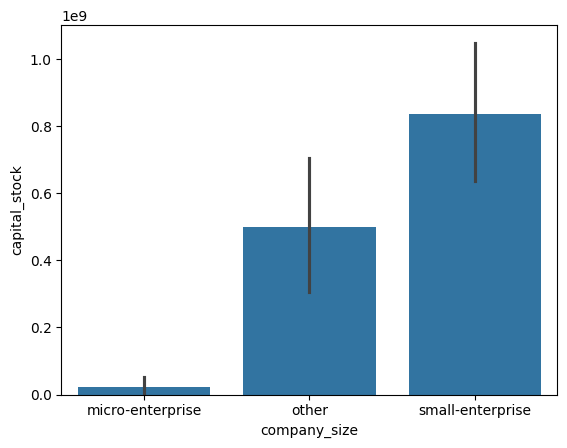

In [ ]:
companies_sorted = companies.sort_values(by='capital_stock', ascending=True)

sns.barplot(x='company_size', y='capital_stock', data=companies_sorted)
plt.show()

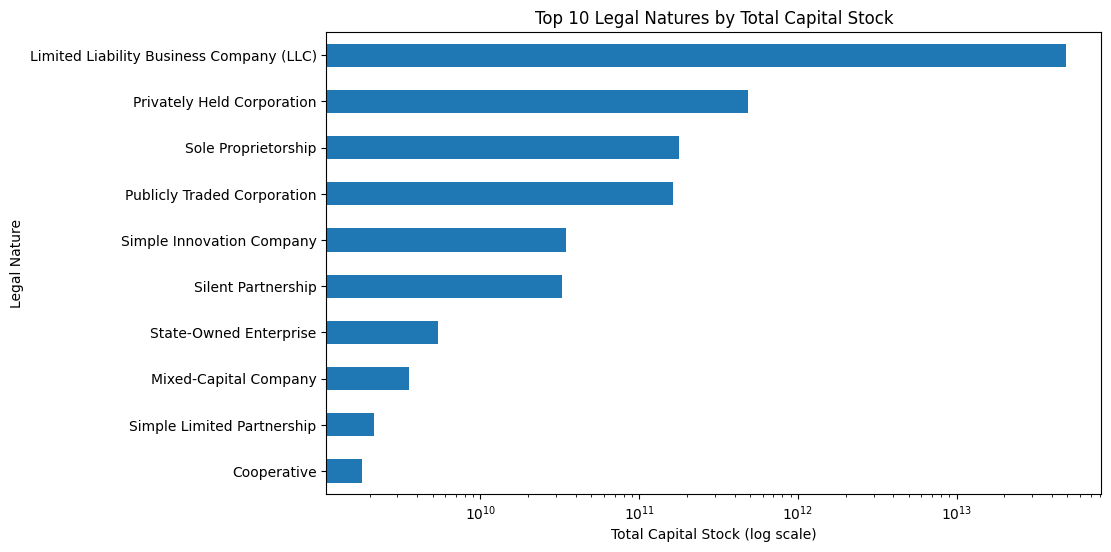

In [28]:
ax = (
    companies.groupby('legal_nature')['capital_stock']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .plot(kind='barh', figsize=(10,6), logx=True)
)

ax.set_xlabel('Total Capital Stock (log scale)')
ax.set_ylabel('Legal Nature')
ax.set_title('Top 10 Legal Natures by Total Capital Stock')
plt.show()

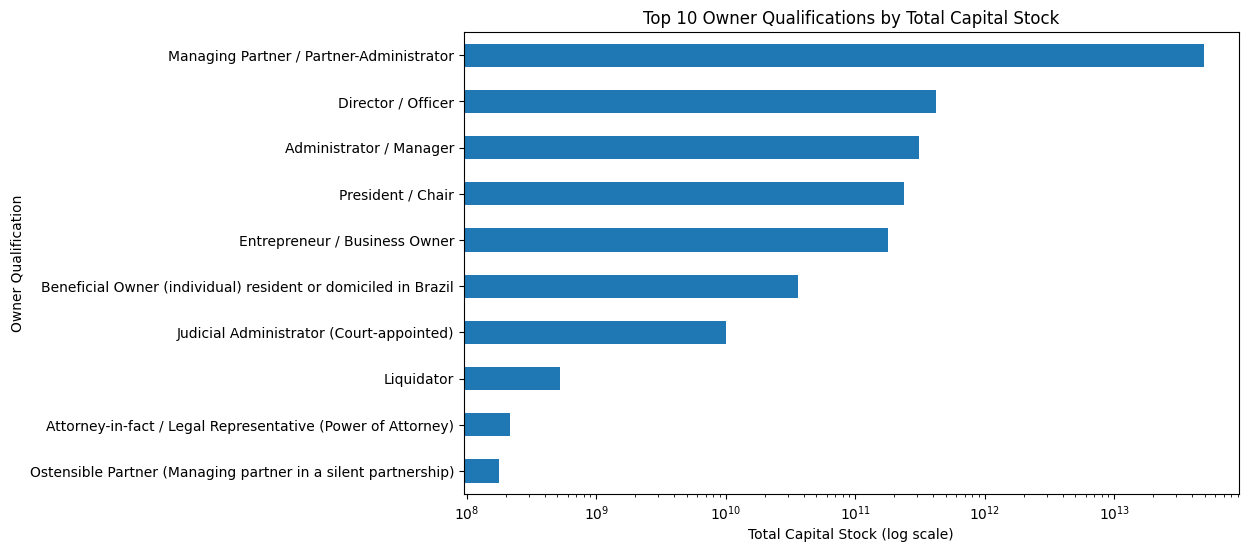

In [30]:
ax = (
    companies.groupby('owner_qualification')['capital_stock']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .plot(kind='barh', figsize=(10,6), logx=True)
)

ax.set_xlabel('Total Capital Stock (log scale)')
ax.set_ylabel('Owner Qualification')
ax.set_title('Top 10 Owner Qualifications by Total Capital Stock')
plt.show()